In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Dataset Class
class ActivityDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32).to(device)
        self.labels = torch.tensor(labels, dtype=torch.long).to(device)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


Using device: mps


In [8]:
class FourierCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FourierCNN, self).__init__()
        
        # Calculate the output size of rfft
        # For real input of length n, rfft output has n//2 + 1 complex values
        self.fft_size = input_size // 2 + 1
        
        # Feature extraction in frequency domain
        self.freq_layer1 = nn.Linear(self.fft_size, 64)
        self.freq_layer2 = nn.Linear(64, 128)
        
        # Final classification layers
        self.fc = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        batch_size = x.size(0)
        
        # Squeeze the channel dimension since we have 1 channel
        x = x.squeeze(1)  # Now shape is [batch_size, input_size]
        
        # Apply FFT along the feature dimension
        # Real FFT for real-valued input
        x_fft = torch.fft.rfft(x, dim=1)
        
        # Get amplitude spectrum (absolute values)
        x_fft = torch.abs(x_fft)  # Shape: [batch_size, fft_size]
        
        # Process in frequency domain
        x = F.relu(self.freq_layer1(x_fft))
        x = F.relu(self.freq_layer2(x))
        
        # Classification
        x = self.dropout(x)
        x = self.fc(x)
        
        return x


In [9]:
def load_data(file_path):
    print("Loading data...")
    df = pd.read_csv(file_path)
    
    # Extract labels (assuming 'activity' column exists)
    if 'activity' in df.columns:
        y = df.pop('activity').values
    elif 'Activity' in df.columns:
        y = df.pop('Activity').values
    else:
        # Find activity column
        label_col = [col for col in df.columns if 'activity' in col.lower() or 'label' in col.lower()]
        if label_col:
            y = df.pop(label_col[0]).values
        else:
            raise ValueError("Could not find activity label column")
    
    # Convert string labels to integers if needed
    if isinstance(y[0], str):
        unique_labels = sorted(set(y))
        label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        y = np.array([label_to_idx[label] for label in y])
        class_names = unique_labels
    else:
        class_names = [str(i) for i in range(len(set(y)))]
    
    # Features are all remaining columns
    X = df.values
    
    # Normalize features
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    
    # For Fourier transform, we need to reshape to (samples, 1, features)
    X = X.reshape(X.shape[0], 1, X.shape[1])
    
    print(f"Data loaded: {X.shape[0]} samples, {X.shape[2]} features, {len(class_names)} classes")
    return X, y, class_names


In [10]:
# 4. Train function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = correct / total
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - "
              f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")
    
    return train_losses, val_losses



In [11]:
# 5. Evaluate function
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate accuracy
    accuracy = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    
    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Print results
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    return accuracy, cm



Loading data...
Data loaded: 1073623 samples, 5 features, 6 classes
Training model...
Epoch 1/10 - Train loss: 1.2852, Train acc: 0.4896 - Val loss: 1.2064, Val acc: 0.5175
Epoch 2/10 - Train loss: 1.2045, Train acc: 0.5174 - Val loss: 1.1603, Val acc: 0.5320
Epoch 3/10 - Train loss: 1.1749, Train acc: 0.5304 - Val loss: 1.1388, Val acc: 0.5433
Epoch 4/10 - Train loss: 1.1619, Train acc: 0.5363 - Val loss: 1.1282, Val acc: 0.5493
Epoch 5/10 - Train loss: 1.1533, Train acc: 0.5398 - Val loss: 1.1158, Val acc: 0.5559
Epoch 6/10 - Train loss: 1.1469, Train acc: 0.5434 - Val loss: 1.1124, Val acc: 0.5587
Epoch 7/10 - Train loss: 1.1417, Train acc: 0.5449 - Val loss: 1.1090, Val acc: 0.5609
Epoch 8/10 - Train loss: 1.1369, Train acc: 0.5467 - Val loss: 1.1024, Val acc: 0.5618
Epoch 9/10 - Train loss: 1.1335, Train acc: 0.5484 - Val loss: 1.0952, Val acc: 0.5631
Epoch 10/10 - Train loss: 1.1306, Train acc: 0.5492 - Val loss: 1.0948, Val acc: 0.5650


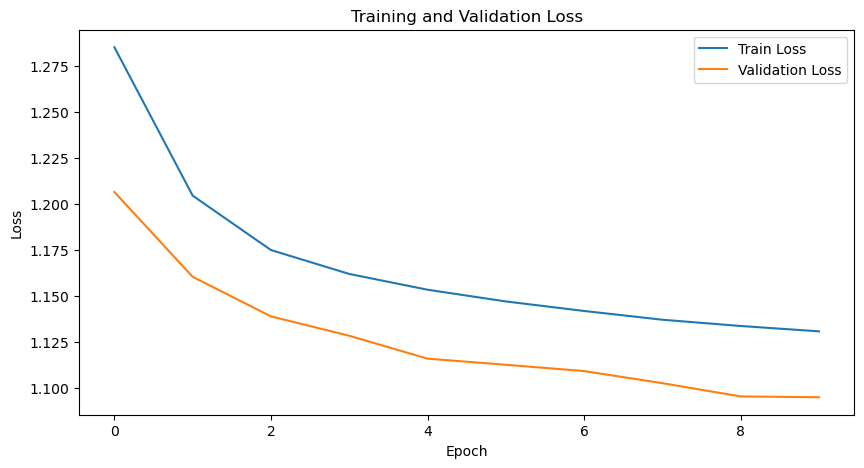


Evaluating model on test data...
Test Accuracy: 0.5644

Classification Report:
              precision    recall  f1-score   support

  Downstairs       0.50      0.00      0.01     14928
     Jogging       0.63      0.53      0.58     48787
     Sitting       0.78      0.95      0.86      9002
    Standing       0.79      0.75      0.77      7265
    Upstairs       0.34      0.01      0.02     18403
     Walking       0.50      0.81      0.62     62659

    accuracy                           0.56    161044
   macro avg       0.59      0.51      0.47    161044
weighted avg       0.55      0.56      0.50    161044



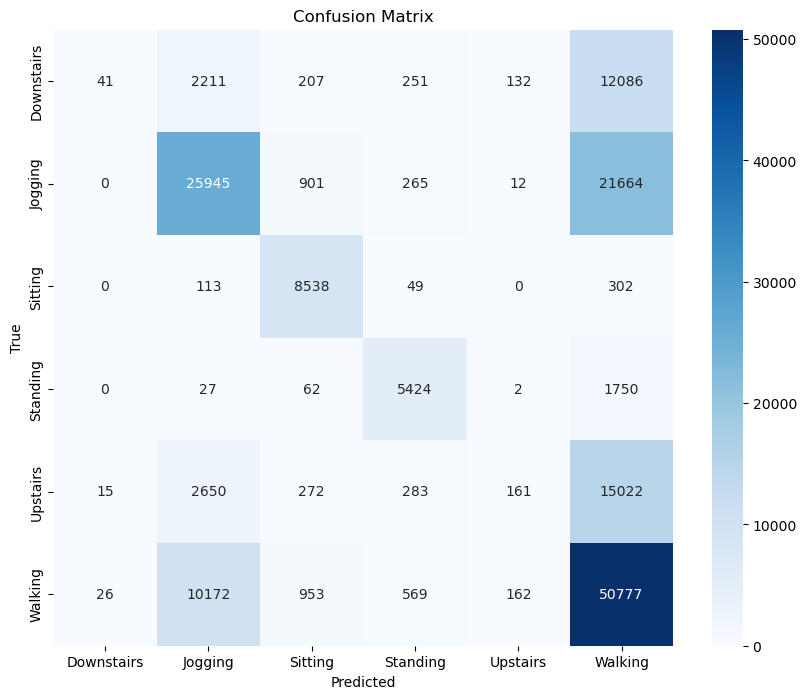

Model saved to activity_recognition_model.pth


In [12]:
def main():
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    
    # Parameters
    data_path = "/Users/janeyan/Desktop/seminar/project 3/time_series_data_human_activities.csv"
    batch_size = 64
    learning_rate = 0.001
    epochs = 10
    
    # Load data
    X, y, class_names = load_data(data_path)
    num_classes = len(set(y))
    input_size = X.shape[2]  # Number of features
    
    # Create dataset
    dataset = ActivityDataset(X, y)
    
    # Split data (70% train, 15% validation, 15% test)
    total_size = len(dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # Initialize model, loss, and optimizer
    model = FourierCNN(input_size, num_classes).to(device)  # Use the Fourier-based model
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train model
    print("Training model...")
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=epochs
    )
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()
    
    # Evaluate model
    print("\nEvaluating model on test data...")
    accuracy, confusion_matrix = evaluate_model(model, test_loader, class_names)
    
    # Save model
    torch.save(model.state_dict(), 'activity_recognition_model.pth')
    print("Model saved to activity_recognition_model.pth")

if __name__ == "__main__":
    main()
